<a href="https://colab.research.google.com/github/Palash0306/credit-risk-scoring-engine/blob/develop/notebooks/06_scorecard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install boto3 pandas numpy scikit-learn xgboost lightgbm \
             pyarrow matplotlib -q

from google.colab import userdata
import os, boto3, io, json, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.environ['AWS_ACCESS_KEY_ID']     = userdata.get('AWS_ACCESS_KEY_ID')
os.environ['AWS_SECRET_ACCESS_KEY'] = userdata.get('AWS_SECRET_ACCESS_KEY')
BUCKET = userdata.get('S3_BUCKET')

s3 = boto3.client('s3')

# Load model + data
obj_model = s3.get_object(Bucket=BUCKET, Key='models/best_model.pkl')
best_model = pickle.loads(obj_model['Body'].read())

obj_data = s3.get_object(Bucket=BUCKET, Key='processed/fct_loans.parquet')
df = pd.read_parquet(io.BytesIO(obj_data['Body'].read()))

obj_cfg = s3.get_object(Bucket=BUCKET, Key='processed/feature_config.json')
config  = json.loads(obj_cfg['Body'].read())
SELECTED = config['selected_features']

print("Setup complete ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 8.2 MB/s eta 0:00:00
Setup complete ✅


In [2]:
# Score every loan in fct_loans
# PD = Probability of Default = model output between 0 and 1
# PD of 0.15 means the model estimates 15% chance of default

X_all = df[SELECTED]
df['pd_score'] = best_model.predict_proba(X_all)[:, 1]

print(f"Scored {len(df):,} loans")
print(f"PD score range  : {df['pd_score'].min():.4f} — {df['pd_score'].max():.4f}")
print(f"Mean PD score   : {df['pd_score'].mean():.4f}")
print(f"Actual default rate: {df['default_flag'].mean():.4f}")

Scored 1,344,936 loans
PD score range  : 0.0054 — 0.9561
Mean PD score   : 0.4417
Actual default rate: 0.1996


In [3]:
# Credit score conversion using log-odds scaling
# This is the standard method used in production credit scorecards
#
# Formula:
#   odds  = PD / (1 - PD)
#   log_odds = ln(odds)
#   credit_score = offset + factor * (-log_odds)
#
# Parameters are set so that:
#   - Score of 600 corresponds to odds of 1:1 (50% default rate)
#   - Score doubles the odds every 20 points (PDO = 20)
#   - Final score is clipped to 300-850 range (standard FICO range)

PDO    = 20      # points to double the odds — standard in credit scoring
OFFSET = 600     # score at which odds = 1:1
FACTOR = PDO / np.log(2)  # scaling factor

def pd_to_credit_score(pd_score, pdo=PDO, offset=OFFSET, factor=FACTOR):
    """
    Convert PD probability to a credit score (300-850).
    Higher score = lower risk = better borrower.
    """
    # Clip PD to avoid log(0) or log(infinity)
    pd_score = np.clip(pd_score, 1e-6, 1 - 1e-6)

    # Convert PD to odds
    odds = pd_score / (1 - pd_score)

    # Convert odds to log-odds
    log_odds = np.log(odds)

    # Invert because higher PD = lower score
    raw_score = offset - factor * log_odds

    # Clip to standard credit score range
    return np.clip(raw_score, 300, 850).astype(int)

df['credit_score'] = pd_to_credit_score(df['pd_score'])

print("Credit score distribution:")
print(df['credit_score'].describe().round(1).to_string())

Credit score distribution:
count    1344936.0
mean         607.9
std           26.9
min          511.0
25%          590.0
50%          606.0
75%          624.0
max          750.0


In [4]:
# Risk tiers group loans into actionable categories
# Banks use these tiers to make lending decisions:
#   Low risk    → approve, best rates
#   Medium risk → approve, standard rates
#   High risk   → approve with conditions or higher rates
#   Very high   → decline or require collateral

def assign_risk_tier(credit_score):
    """
    Map credit score to risk tier.
    Thresholds align with industry standard cut-offs.
    """
    if credit_score >= 720:
        return 'low'
    elif credit_score >= 660:
        return 'medium'
    elif credit_score >= 580:
        return 'high'
    else:
        return 'very_high'

df['risk_tier'] = df['credit_score'].apply(assign_risk_tier)

print("Risk tier distribution:")
tier_stats = df.groupby('risk_tier').agg(
    count=('default_flag', 'count'),
    default_rate=('default_flag', 'mean'),
    avg_credit_score=('credit_score', 'mean')
).round(4)
print(tier_stats.to_string())

Risk tier distribution:
             count  default_rate  avg_credit_score
risk_tier                                         
high       1107717        0.1667          611.4308
low            107        0.0000          725.2523
medium       53876        0.0183          673.2653
very_high   183236        0.4522          567.3560


In [5]:
# Score bands break the 300-850 range into 10 equal bands
# Each band shows population count and default rate
# This is the "scorecard" that credit analysts read

df['score_band'] = pd.cut(
    df['credit_score'],
    bins=[300, 400, 450, 500, 550, 580, 620, 660, 700, 750, 850],
    labels=['300-400','400-450','450-500','500-550','550-580',
            '580-620','620-660','660-700','700-750','750-850']
)

scorecard = df.groupby('score_band', observed=True).agg(
    population=('default_flag', 'count'),
    defaults=('default_flag', 'sum'),
    default_rate=('default_flag', 'mean'),
    avg_pd=('pd_score', 'mean'),
    avg_credit_score=('credit_score', 'mean')
).round(4)
scorecard['pct_population'] = (scorecard['population'] / len(df)).round(4)

print("Full Scorecard:")
print(scorecard.to_string())

Full Scorecard:
            population  defaults  default_rate  avg_pd  avg_credit_score  pct_population
score_band                                                                              
500-550          12126      8065        0.6651  0.8681          544.8479          0.0090
550-580         183095     78982        0.4314  0.7342          569.6743          0.1361
580-620         752122    156362        0.2079  0.4843          601.3632          0.5592
620-660         346646     24164        0.0697  0.2338          634.7867          0.2577
660-700          49410       909        0.0184  0.0754          673.1139          0.0367
700-750           1537         6        0.0039  0.0233          707.9551          0.0011


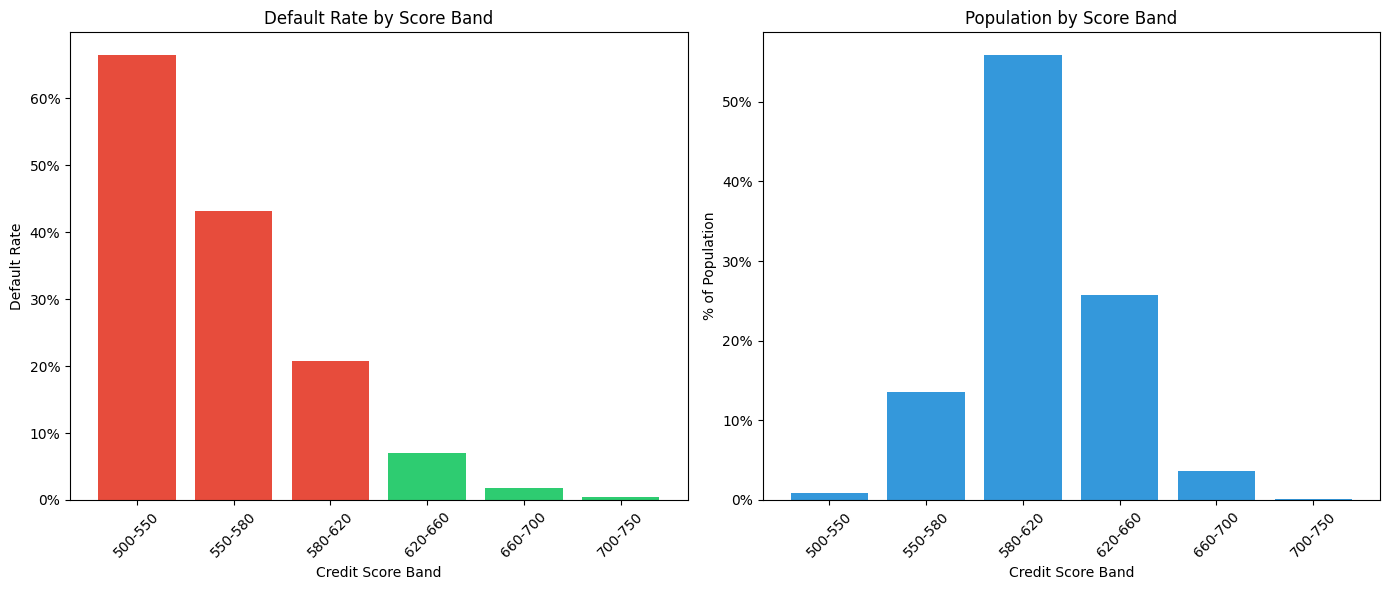

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Default rate by score band
bands = scorecard.index.astype(str)
ax1.bar(bands, scorecard['default_rate'],
        color=['#e74c3c' if r > 0.20 else '#f39c12' if r > 0.10
               else '#2ecc71' for r in scorecard['default_rate']])
ax1.set_title('Default Rate by Score Band')
ax1.set_xlabel('Credit Score Band')
ax1.set_ylabel('Default Rate')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Population distribution
ax2.bar(bands, scorecard['pct_population'], color='#3498db')
ax2.set_title('Population by Score Band')
ax2.set_xlabel('Credit Score Band')
ax2.set_ylabel('% of Population')
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig('/tmp/scorecard.png', dpi=150)
plt.show()

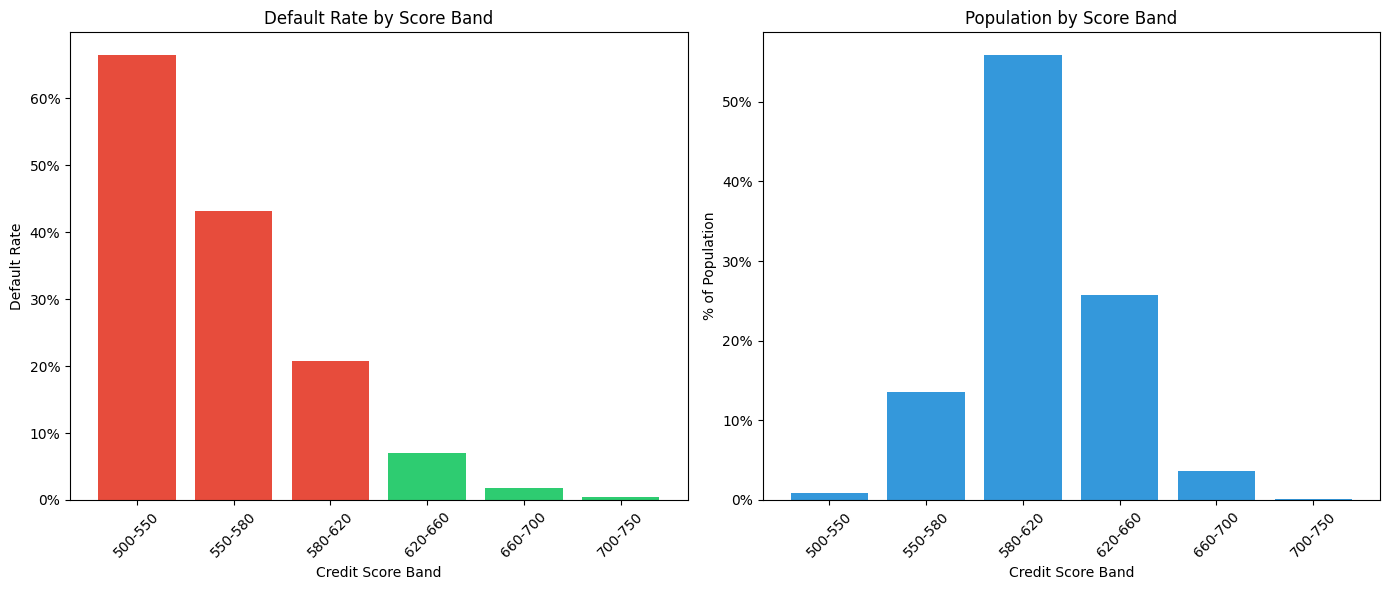

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Default rate by score band
bands = scorecard.index.astype(str)
ax1.bar(bands, scorecard['default_rate'],
        color=['#e74c3c' if r > 0.20 else '#f39c12' if r > 0.10
               else '#2ecc71' for r in scorecard['default_rate']])
ax1.set_title('Default Rate by Score Band')
ax1.set_xlabel('Credit Score Band')
ax1.set_ylabel('Default Rate')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Population distribution
ax2.bar(bands, scorecard['pct_population'], color='#3498db')
ax2.set_title('Population by Score Band')
ax2.set_xlabel('Credit Score Band')
ax2.set_ylabel('% of Population')
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig('/tmp/scorecard.png', dpi=150)
plt.show()